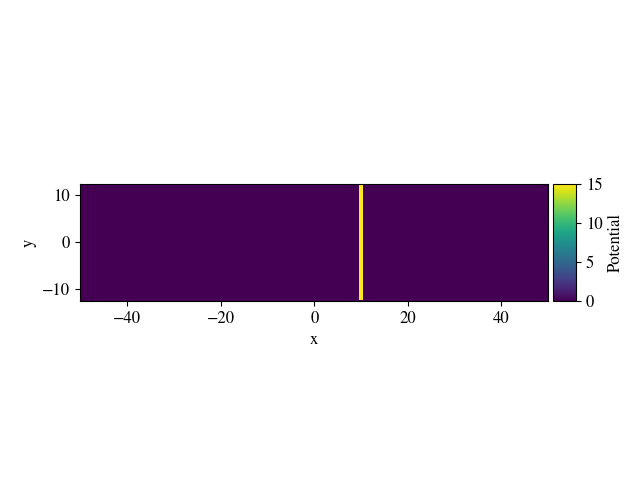

In [21]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from bloch_schrodinger.potential import Potential, create_parameter
from BECs.groundstate import normalize
from BECs.ssfm import SSFM
from BECs.ufuncs import gaussian2D

%matplotlib widget

lx, ly = 100,25
nres = 8

barrier = Potential(
    [[lx,0],[0,ly]],
    (2**(nres+1), 2**(nres-1)),
    v0 = 0
)

width = create_parameter('width', np.linspace(1, 5, 2))
height = create_parameter('height', np.linspace(15, 50, 1))
k = create_parameter('k', np.linspace(2, 5, 1))
# g = create_parameter('g', np.linspace(2, 20, 2))
g = 0


barrier.rectangle(
    (10, 0), (width, ly*1), value = height
)

k = 3
sig = 3
psi0 = gaussian2D(barrier.x, barrier.y, -lx/5, 0, sig, sig, 1) * np.exp(1j * -k * barrier.x)
psi0 = normalize(psi0, 200**0.5)

fig, ax = barrier.plot()
plt.show()

In [ ]:
solv = SSFM(
    barrier,
    psi0,
    g
)

solv.add_losses(0.1, 2)

ti, tf = 0, 10
samples = create_parameter("t", np.linspace(ti, tf, 200))
psi = solv.solve(
    ti, tf, samples, parallelize=True, n_cores = 2, verbose = True
)

[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   1 tasks      | elapsed:   28.9s
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:   29.2s finished


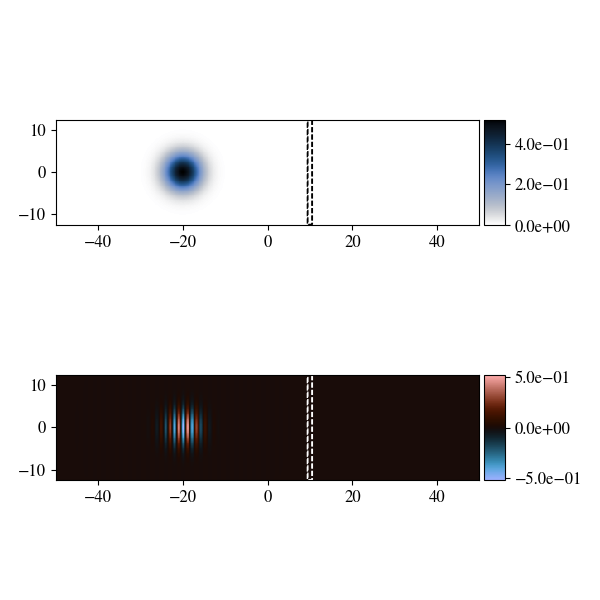

In [25]:
from bloch_schrodinger.plotting import plot_cuts, plot_eigenvector, get_template

amp = get_template('amplitude')
amp['contourkwargs']["levels"] = 1

real = get_template('real')
real['contourkwargs']["levels"] = 1

phase = get_template('phase')
phase['contourkwargs']["levels"] = 1

sel = dict(a1=slice(-0.5,0.5))
tp = psi.sel(sel)
barrier_sel = barrier.copy()
barrier_sel.V = barrier.V.sel(sel)
fig, axes = plot_eigenvector(
    [[abs(tp)], [tp.real]],
    [[barrier_sel], [barrier_sel]],
    [[amp], [real]]
)
plt.show()

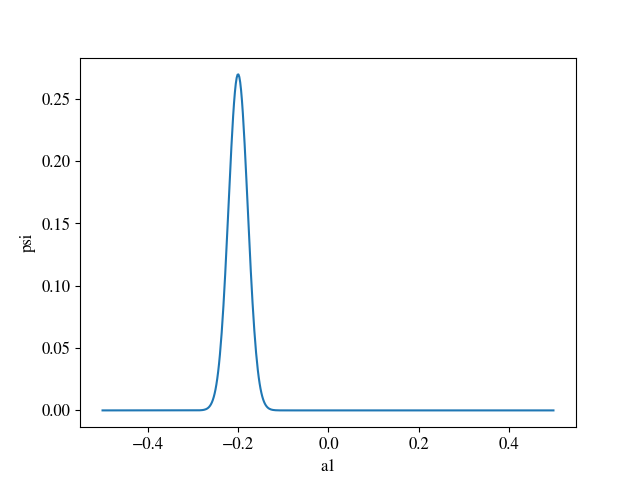

In [24]:
%reload_ext autoreload
%autoreload 2

fig, ax = plot_cuts(
    abs(psi.sel(a2=0, method = 'nearest'))**2,
    'a1',
    groupby=(),
    # ymin = -1e-1,
    # ymax = 5e-1
)
plt.show()